# Imports

In [1]:
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fashion Mnist Data

In [6]:
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# https://www.openml.org/search?type=data&sort=runs&id=40996&status=active
# https://www.kaggle.com/datasets/zalando-research/fashionmnist

data = sklearn.datasets.fetch_openml('Fashion-MNIST', as_frame=False)

In [13]:
data.details

{'id': '40996',
 'name': 'Fashion-MNIST',
 'version': '1',
 'description_version': '1',
 'format': 'ARFF',
 'creator': ['Han Xiao', 'Kashif Rasul', 'Roland Vollgraf'],
 'upload_date': '2017-12-20T13:28:27',
 'licence': 'Public',
 'url': 'https://openml.org/data/v1/download/18238735/Fashion-MNIST.arff',
 'parquet_url': 'https://data.openml.org/datasets/0004/40996/dataset_40996.pq',
 'file_id': '18238735',
 'default_target_attribute': 'class',
 'version_label': '1.0',
 'citation': '@online{xiao2017/online,\n  author       = {Han Xiao and Kashif Rasul and Roland Vollgraf},\n  title        = {Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms},\n  date         = {2017-08-28},\n  year         = {2017},\n  eprintclass  = {cs.LG},\n  eprinttype   = {arXiv},\n  eprint       = {cs.LG/1708.07747},\n}',
 'tag': ['Artificial Intelligence',
  'Computer Vision',
  'Data Sets',
  'Machine Learning',
  'OpenML-CC18',
  'study_218',
  'study_99',
  'vision'],
 'visibility

In [8]:
# Q1 (1 points) What are the shapes of X, y
X, y = data.data, data.target
print("X shape:", X.shape)
print("y shape:", y.shape)



X shape: (70000, 784)
y shape: (70000,)


In [11]:
# Q2 (1 point) How many different classes in y?
classnames = data.categories['class']
classnames

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

In [14]:
# Q3 (1 point) What is range of values for each pixel?
print("Min pixel value:", X.min())
print("Max pixel value:", X.max())

Min pixel value: 0
Max pixel value: 255


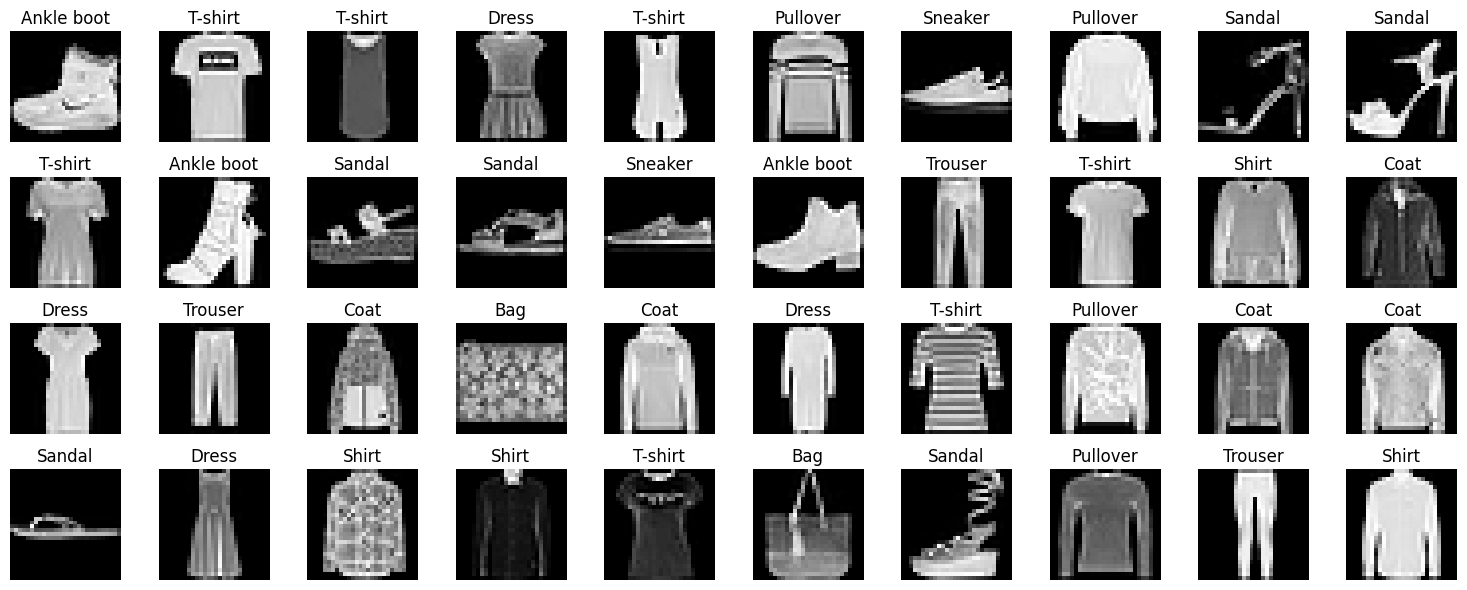

In [15]:
# Q4 (1 point) Display first 40 images in [4, 10] grid with labels

# Define class names
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

fig, axes = plt.subplots(4, 10, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    img = X[i].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(class_names[int(y[i])])
    ax.axis('off')

plt.tight_layout()
plt.show()

# Build a multiclass classifier

In [16]:
# Q5 (1 point) Do train/test split. Train SGDClassifier on all classes. Show
# precision_score and recall_score with average=None on the test split.

from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import precision_score, recall_score

# Step 1: Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42     # for reproducibility
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

#SGDCclassifier
sgd = SGDClassifier(random_state=42)
sgd.fit(X_train, y_train)

y_pred = sgd.predict(X_test)


class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

precision = precision_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)



print("\nClass          Precision   Recall")
print("-" * 40)
for i, name in enumerate(class_names):
    print(f"{name:<15} {precision[i]:.3f}      {recall[i]:.3f}")


X_train shape: (56000, 784)
X_test shape: (14000, 784)

Class          Precision   Recall
----------------------------------------
T-shirt         0.771      0.799
Trouser         0.930      0.969
Pullover        0.783      0.614
Dress           0.952      0.580
Coat            0.507      0.915
Sandal          0.972      0.848
Shirt           0.677      0.446
Sneaker         0.907      0.926
Bag             0.834      0.966
Ankle boot      0.904      0.964


# Build a binary classifier for 5 (sandal) vs 7 (sneaker)

In [18]:
# Q6 (1 point) prepare train and test sets for 5 vs 7.

# Step 1: Filter only class 5 (sandal) and class 7 (sneaker)
mask = (y == '5') | (y == '7')
X_binary = X[mask]
y_binary = y[mask]



X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_binary, y_binary,
    test_size=0.2,
    random_state=42
)

print("\nX_train_b shape:", X_train_b.shape)
print("X_test_b shape:", X_test_b.shape)



X_train_b shape: (11200, 784)
X_test_b shape: (2800, 784)


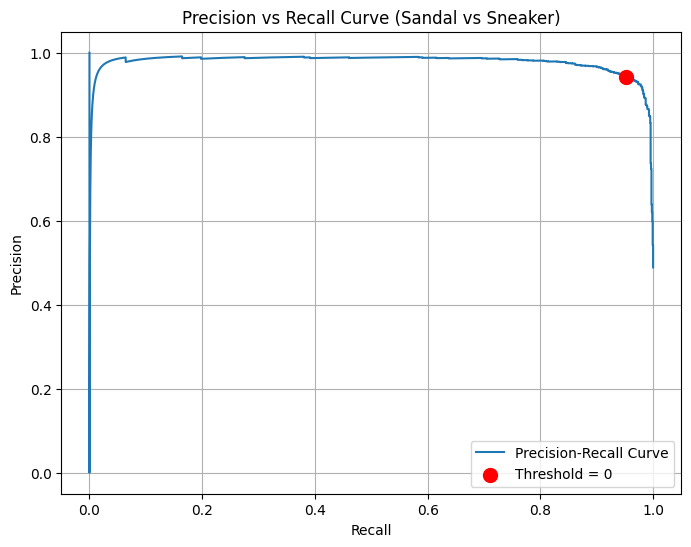


At threshold=0:
Precision: 0.941
Recall:    0.951


In [23]:
# Q7 (1 point) Train SGDClassifier. Plot precision (y-axis) vs recall (x-axis)
# curve. Show where the threshold=0 point is.

from sklearn.metrics import precision_recall_curve
sgd_binary = SGDClassifier(random_state=42)
sgd_binary.fit(X_train_b, y_train_b)




y_scores = sgd_binary.decision_function(X_test_b)
precisions, recalls, thresholds = precision_recall_curve(y_test_b, y_scores, pos_label='7')


threshold_0_idx = np.argmin(np.abs(thresholds - 0))


plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, label='Precision-Recall Curve')
plt.scatter(recalls[threshold_0_idx], precisions[threshold_0_idx],
            color='red', s=100, zorder=5, label='Threshold = 0')


plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision vs Recall Curve (Sandal vs Sneaker)')
plt.legend()
plt.grid(True)
plt.show()


print(f"\nAt threshold=0:")
print(f"Precision: {precisions[threshold_0_idx]:.3f}")
print(f"Recall:    {recalls[threshold_0_idx]:.3f}")



# Implement precision vs recall curve

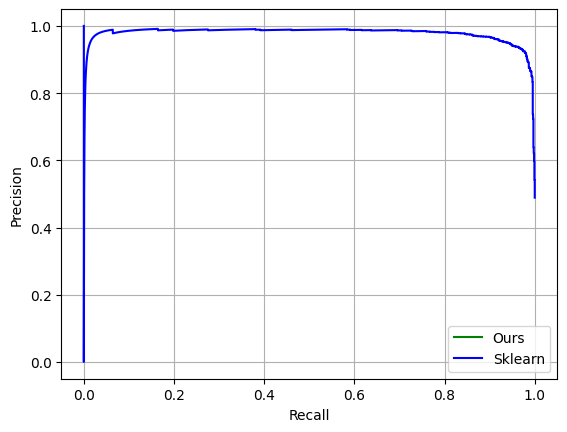

In [26]:
# Q8 (3 points) Write your function (using numpy) to compute triple {precision,
# recall, threshold} for thresholds in range [-100..100] (or range [0..1] if after
# sigmoid) and use it with the binary classifier you trained above and compare
# with the plot you got above.

def my_precision_recall_curve(y_true, y_scores, thresholds):
    precisions, recalls = [], []

    for t in thresholds:
        y_pred = (y_scores > t)

        TP = np.sum((y_pred == True)  & (y_true == True))
        FP = np.sum((y_pred == True)  & (y_true == False))
        FN = np.sum((y_pred == False) & (y_true == True))

        precisions.append(TP / (TP + FP) if (TP + FP) > 0 else 1.0)
        recalls.append(TP / (TP + FN)    if (TP + FN) > 0 else 0.0)

    return np.array(precisions), np.array(recalls)


thresholds    = np.linspace(-100, 100, 1000)
y_true_binary = (y_test_b == '7')
my_prec, my_rec = my_precision_recall_curve(y_true_binary, y_scores, thresholds)


plt.plot(my_rec,  my_prec,  color='green', label='Ours')
plt.plot(recalls, precisions, color='blue', label='Sklearn')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)
plt.show()


